<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 171.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 155.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 140.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
## Write your code here
duplicate_count = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_count}")


Total number of duplicate rows: 20

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [7]:
## Write your code here
import pandas as pd

# Define the core columns to group by
pattern_columns = ['MainBranch', 'Employment', 'RemoteWork']

# 1. Identify and Count the Response Patterns
# We keep all instances (keep=False) to see every respondent who fits a shared pattern
pattern_duplicates = df[df.duplicated(subset=pattern_columns, keep=False)]
total_pattern_respondents = len(pattern_duplicates)

print(f"Clarification: These {total_pattern_respondents} rows represent individual respondents ")
print("who provided identical answers to these specific questions, not duplicate records.\n")

# 2. View the most common response patterns
pattern_counts = df.groupby(pattern_columns).size().reset_index(name='RespondentCount')
top_patterns = pattern_counts.sort_values(by='RespondentCount', ascending=False)

print("Top 5 Most Common Response Patterns:")
print(top_patterns.head())

# 3. Analyze which OTHER columns frequently share identical values within these groups
print("\nAnalyzing shared values in other columns...")

# We loop through all columns except our core pattern columns
for col in df.columns:
    if col not in pattern_columns:
        # Group by the pattern and find how many unique values exist in the 'other' column
        unique_counts = df.groupby(pattern_columns)[col].nunique()
        
        # If a column has an average of close to 1 unique value per group, 
        # it means respondents in these groups answer this 'other' column identically too.
        avg_unique = unique_counts.mean()
        
        # A threshold near 1.0 means highly identical answers
        if avg_unique < 1.5: 
            print(f"- Column '{col}' frequently shares identical values within the pattern groups (Avg unique values: {avg_unique:.2f})")


Clarification: These 65290 rows represent individual respondents 
who provided identical answers to these specific questions, not duplicate records.

Top 5 Most Common Response Patterns:
                        MainBranch  \
0   I am a developer by profession   
2   I am a developer by profession   
1   I am a developer by profession   
78  I am a developer by profession   
8   I am a developer by profession   

                                           Employment  \
0                                 Employed, full-time   
2                                 Employed, full-time   
1                                 Employed, full-time   
78  Independent contractor, freelancer, or self-em...   
8   Employed, full-time;Independent contractor, fr...   

                              RemoteWork  RespondentCount  
0   Hybrid (some remote, some in-person)            15288  
2                                 Remote            12196  
1                              In-person             7118  
7

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [9]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.

Visualizing data for the most common shared pattern:
'I am a developer by profession | Employed, full-time | Hybrid (some remote, some in-person)'


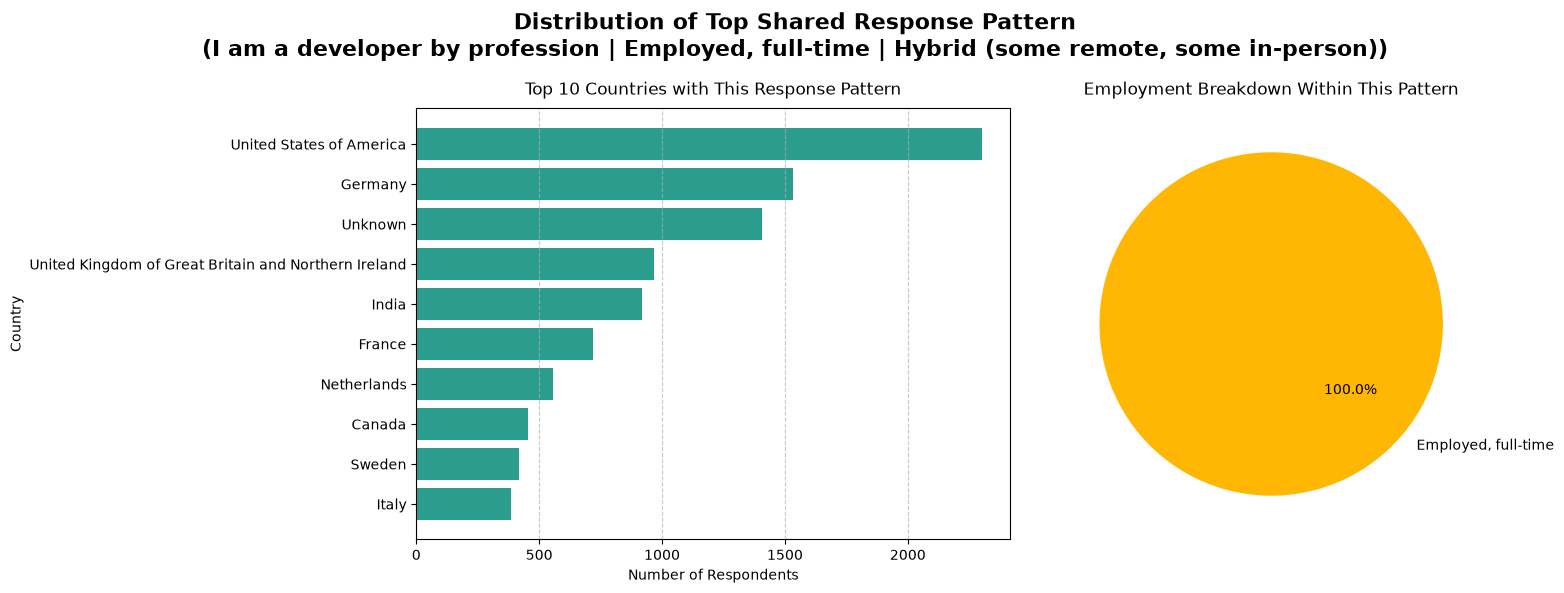

In [12]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Data Preparation ---
pattern_columns = ['MainBranch', 'Employment', 'RemoteWork']

# Convert columns to string AND fill any missing (NaN) values with 'Missing'
df_str = df[pattern_columns].astype(str).fillna('Missing')

# Safely combine the columns into a single text profile string
df['ResponseProfile'] = df_str.agg(' | '.join, axis=1)

# Find the most common shared profile
top_profile = df['ResponseProfile'].value_counts().idxmax()
profile_data = df[df['ResponseProfile'] == top_profile]

print(f"Visualizing data for the most common shared pattern:\n'{top_profile}'\n")

# --- 2. Visualization Setup ---
# axes will be an array of length 2: axes[0] and axes[1]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Distribution of Top Shared Response Pattern\n({top_profile})", fontsize=16, fontweight='bold')

# --- Chart 1: Bar Chart (Top 10 Countries - Plotted on axes[0]) ---
country_data = profile_data['Country'].fillna('Unknown')
top_countries = country_data.value_counts().head(10).sort_values(ascending=True)

axes[0].barh(top_countries.index, top_countries.values, color='#2a9d8f')
axes[0].set_title("Top 10 Countries with This Response Pattern", fontsize=12, pad=10)
axes[0].set_xlabel("Number of Respondents")
axes[0].set_ylabel("Country")
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# --- Chart 2: Pie Chart (Employment Breakdown - Plotted on axes[1]) ---
employment_data = profile_data['Employment'].fillna('Unknown')
employment_counts = employment_data.value_counts().head(5)
colors = ['#ffb703', '#fb8500', '#219ebc', '#023047', '#8ecae6']

axes[1].pie(
    employment_counts, 
    labels=employment_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors[:len(employment_counts)],
    wedgeprops={'edgecolor': 'w', 'linewidth': 1}
)
axes[1].set_title("Employment Breakdown Within This Pattern", fontsize=12, pad=10)

# Adjust layout and display
plt.tight_layout()
plt.show()


### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
